In [38]:
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import mplhep as hep
hep.style.use("CMS")

plt.rcParams['figure.facecolor']='white'
plt.rcParams['savefig.facecolor']='white'
plt.rcParams['savefig.bbox']='tight'
plt.rcParams['legend.frameon']=True
plt.rcParams['legend.edgecolor']='white'
import uproot#glob,ROOT

from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (10, 8)

import gc

In [39]:
from io import StringIO
import pandas as pd
calc_str = StringIO("""nu,nb_D0,nb_D0star
    8.75,7.5,0
    8.85,12.9,0
    8.95,17.0,0
    9.05,19.7,0
    9.15,21.8,0
    9.25,23.8,0
    9.35,25.2,0
    9.45,26.5,21.8
    9.55,27.2,30.6
    9.65,28.2,36.4
    9.75,29.3,40.8
    9.85,29.9,44.9
    9.95,30.6,47.6
    10.05,31.3,50.3
    """)

calc = pd.read_csv(calc_str, sep=",")

calc_str = StringIO("""nu,nb_D0,nb_D0star
    8.714, 0,0
    8.72,3.4,0
    8.73,4.76,0
    8.75,7.5,0
    8.85,12.9,0
    8.95,17.0,0
    9.05,19.7,0
    9.15,21.8,0
    9.25,23.8,0
    9.35,25.2,0
    9.362,25.3,6.8
    9.41,25.9,16.3
    9.45,26.5,21.8
    9.55,27.2,30.6
    9.65,28.2,36.4
    9.75,29.3,40.8
    9.85,29.9,44.9
    9.95,30.6,47.6
    10.05,31.3,50.3
    """)

9354.4,0.0
9381.2,11.6
9385.1,25.9
9408.0,16.3
9408.0,25.9
9431.0,19.7
9431.0,25.9
9362.1,6.8
9362.1,25.2

calc_smooth = pd.read_csv(calc_str, sep=",")

/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_1332/1128405914.py:16: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(nu,1700*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2)))
/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_1332/1128405914.py:22: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(nu,3800*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2)))


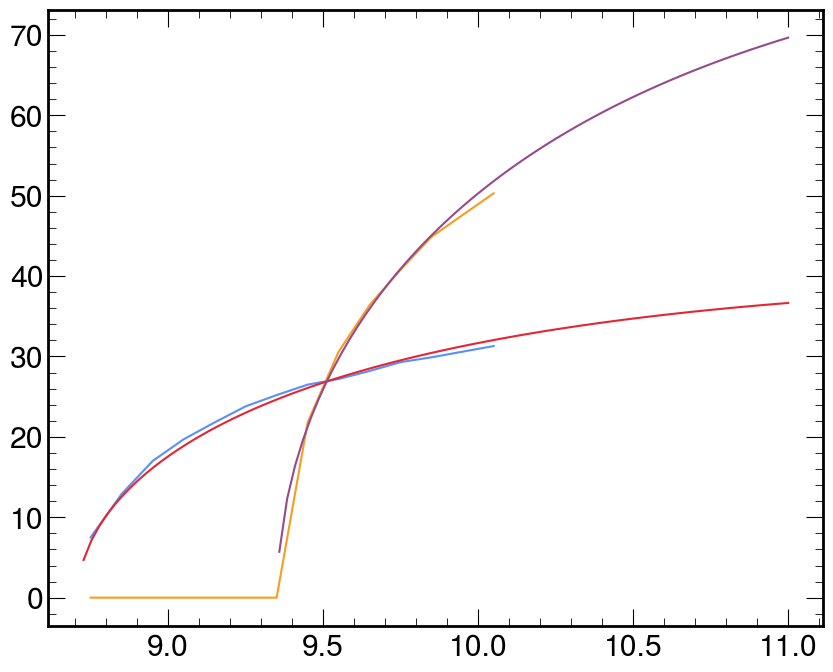

In [40]:
plt.plot(calc.nu, calc.nb_D0)
plt.plot(calc.nu, calc.nb_D0star)

x=np.linspace(8.5,11, 100)

#plt.plot(x,28*np.maximum(x-8.72,0)**.35)
#plt.plot(x,55*np.maximum(x-9.35,0)**.37)

nu=x
s=.9383**2+2*nu*.9383
m1=2.286
m2=1.864
def lfunc(a,b,c):
    return a**2+b**2+c**2-2*a*b-2*b*c-2*a*c
    
plt.plot(nu,1700*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2)))

nu=x
s=.9383**2+2*nu*.9383
m1=2.286
m2=2.007
plt.plot(nu,3800*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2)))





In [45]:
pF_C=.221
pF_W=.265

In [51]:
#approximation for the total xs for stationary target


def lfunc(a,b,c):
    r=(a**2+b**2+c**2-2*a*b-2*b*c-2*a*c)
    return r+(-r)*(r<0)

def fnc1(nu):
    s=.9383**2+2*nu*.9383
    m1=2.286
    m2=1.864
    return 1700*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2))
    
def fnc2(nu):
    s=.9383**2+2*nu*.9383
    m1=2.286
    m2=2.007
    return 3800*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2))

def fnc(nu):
    return fnc1(nu)+fnc2(nu)

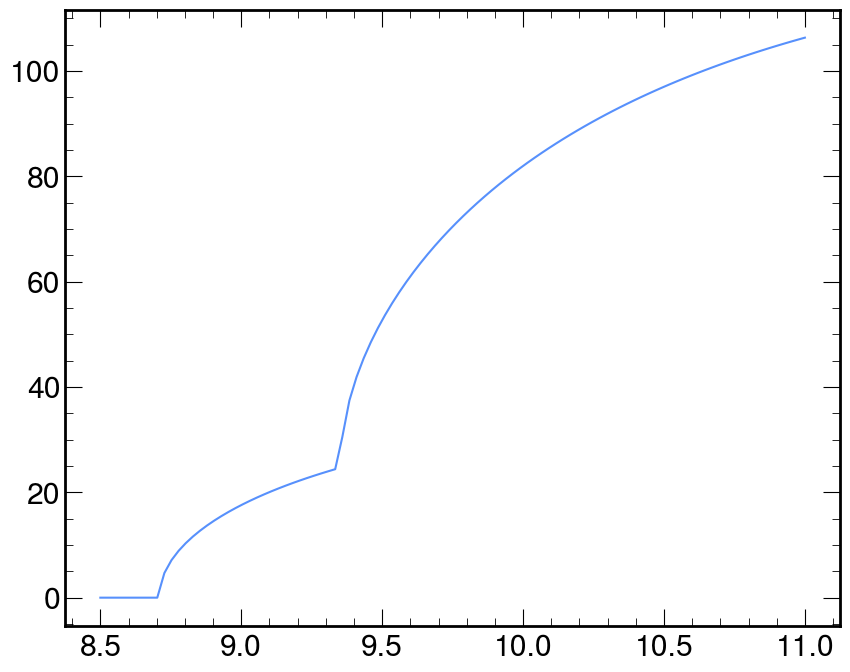

In [52]:

x=np.linspace(8.5,11, 100)
plt.plot(x, fnc(x))

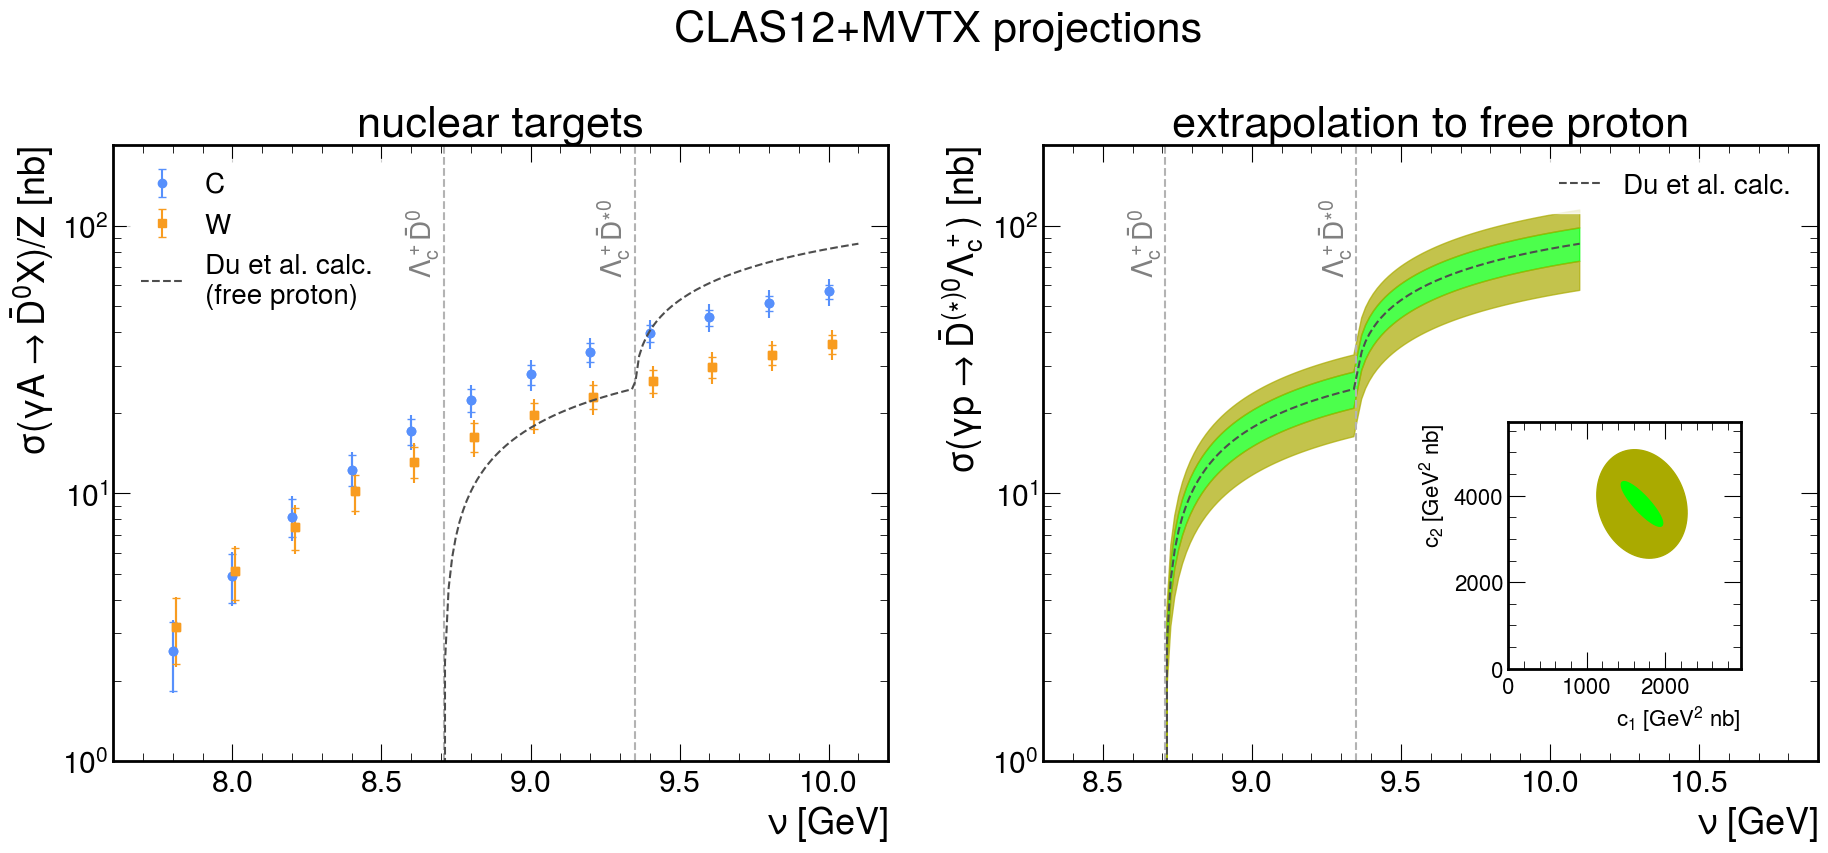

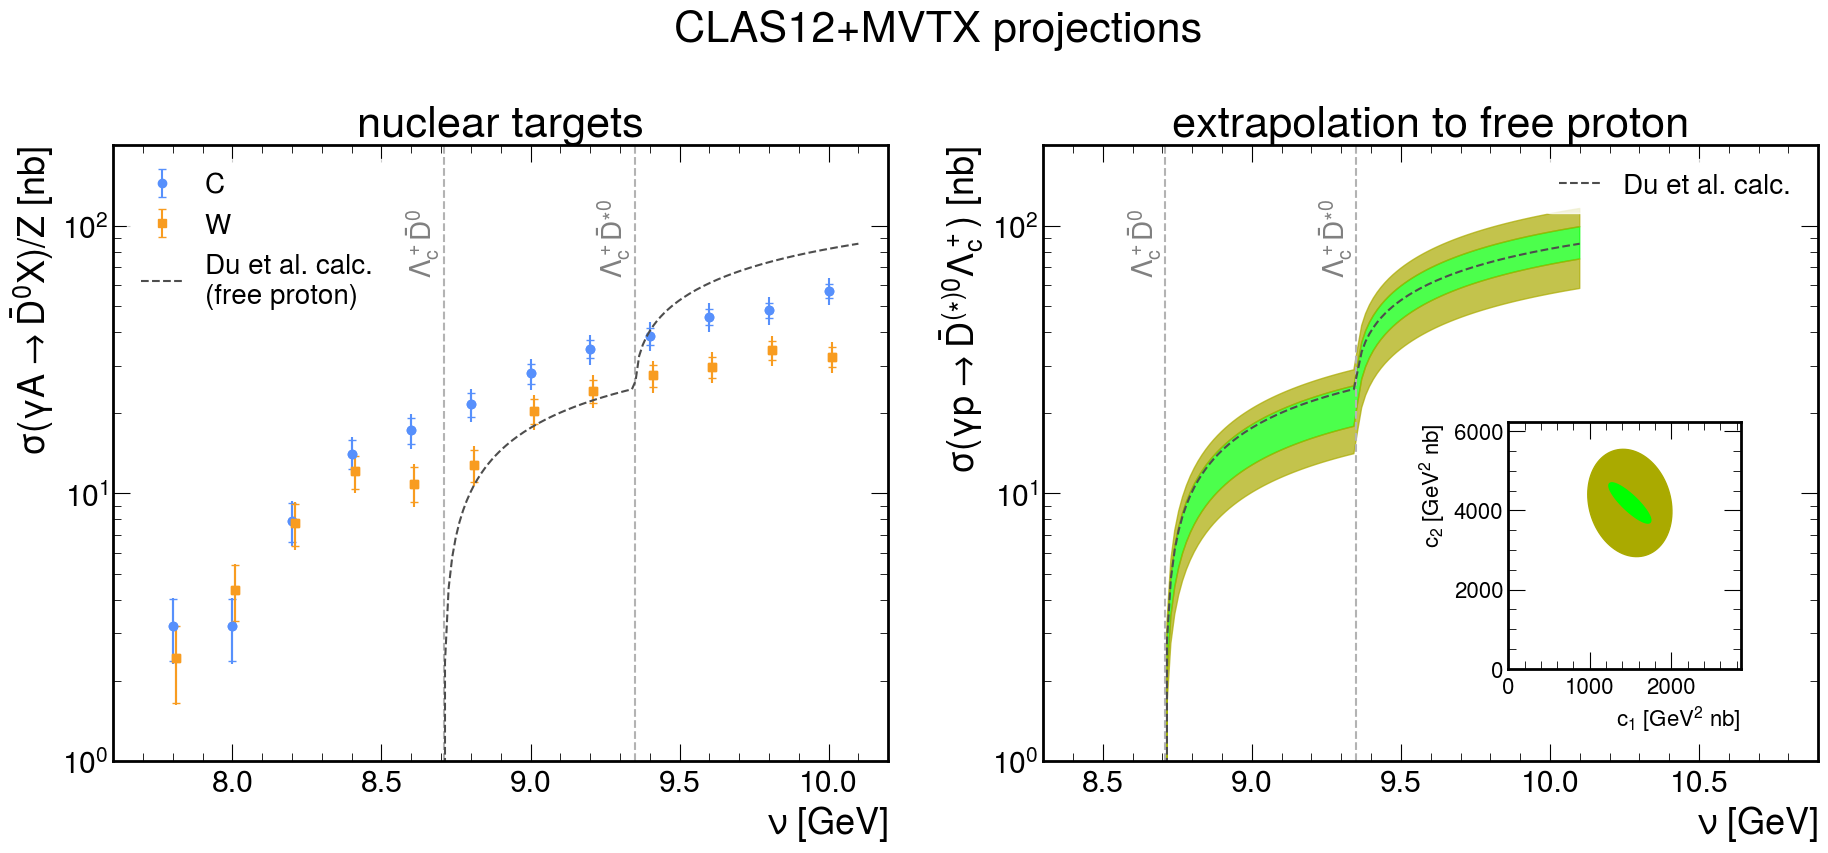

In [191]:
for do_raffle in False,True:
    fig, axs=plt.subplots(1,2,figsize=(22,8))#, sharey='all')
    plt.sca(axs[0])
    
    
    #smear function
    aa=[]
    npoints=100
    a=np.linspace(-1, 1,npoints+1)[None,:]
    #integral 1-x^2 = x-x^3/3  -> (1-1/3)*2=4/3
    w=(1-a**2)*(2/npoints)/(4/3)
    
    
    
    nubins=12
    numin,numax=7.7,10.1
    
    bc=np.linspace(numin+(numax-numin)/(2*nubins), numax-(numax-numin)/(2*nubins), nubins)
    
    
    xvals={}
    yvals={}
    dyvals={}
    
    scale_lumi=3
    
    for pF,scale,N, lbl, marker,shift in (pF_C,.85, scale_lumi*504, "C",'o', 0), (pF_W,.55, scale_lumi*307, "W",'s', 0.01):
        sigma=scale*np.sum(fnc(x[:,None]*(1-a*pF/.9383))*w,axis=-1)
        #plt.plot(x,sigma, label=lbl)
        
        
        sigma=scale*np.sum(fnc(bc[:,None]*(1-a*pF/.9383))*w,axis=-1)
        Ni=sigma*N/np.sum(sigma)

        if do_raffle:
            Ni_raffled=np.random.poisson(Ni)
        else:
            Ni_raffled=Ni
        
        sigma_raffled=sigma*Ni_raffled/Ni
        dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
        b=plt.errorbar(bc+shift,sigma_raffled,dsigma_raffled, label=lbl, ls='', marker=marker, capsize=3)
        aa.append(b)
        
        #also show with systematic errors
        plt.errorbar(bc+shift,sigma_raffled,np.hypot(dsigma_raffled,sigma_raffled*.1), ls='', marker=marker, color=b[0].get_color())
        
        #keep track of the values for both targets
        xvals[lbl]=bc
        yvals[lbl]=sigma_raffled
        dyvals[lbl]=dsigma_raffled
        
        #plt.plot(x,scale*np.sum(fnc1(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)
        #plt.plot(x,scale*np.sum(fnc2(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)
    
    plt.yscale('log')
    
    for i in 0,1:
        thr=[8.71,9.35][i]
        plt.axvline(thr, ls='--', color='0.7')
        txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
        plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)
    
    axs[0].set_ylim(1, 2e2)
    axs[1].set_ylim(*axs[0].get_ylim())
    axs[1].set_yscale('log')
    axs[0].set_ylabel("$\\sigma(\\gamma A\\rightarrow \\bar D^{0}X)/Z$ [nb]")
    axs[1].set_ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$ [nb]")
    plt.xlabel("$\\nu$ [GeV]")
    plt.title("nuclear targets")
    
    
    x=np.linspace(7.7,10.1, 200)
    aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.\n(free proton)', ls='--', color='0.3'))
    
    plt.legend(fontsize=20, loc='upper left')
    
    
    plt.sca(axs[1])
    
    
    # Approximation for function from the paper, split into D0bar and D0bar* parts.  
    #relative_scale
    def fit_fnc_no_smear(nu,c1,c2):
        #return p1*(np.maximum(x-8.71,0)**.35+ relative_scale*55/28*np.maximum(x-9.35,0)**.37)
        s=.9383**2+2*nu*.9383
        m1=2.286
        m2=1.864
        m3=2.007
        return (c1*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2))+c2*np.sqrt(lfunc(s,m1**2,m3**2))/(s*(s-.9383**2)))
    
        
        
    def fit_fnc(x, c1, c2,k):
        nu,A=x
        #print(nu,A)
        f = fit_fnc_no_smear
        pF=pF_C*(A==12)+pF_W*(A==184)
        return np.exp(-k*(A**(1/3)-1))*np.sum(f(nu[:,None]*(1-a*pF[:,None]/.9383),c1,c2)*w,axis=-1) 
    
    
    from scipy.optimize import curve_fit
    P0=1000,3000,-0.1
    
    xvals=np.array([np.concatenate([xvals['C'],xvals['W']]), np.array([12]*len(xvals['C'])+[184]*len(xvals['W']))])
    yvals=np.concatenate([yvals['C'],yvals['W']])
    dyvals=np.concatenate([dyvals['C'],dyvals['W']])
    #print(yvals,dyvals)
    P, cov = curve_fit(fit_fnc, xvals, yvals, p0=P0, sigma=dyvals,absolute_sigma=True)
    #params[lbl]=np.abs(P)
    #covs[lbl]=cov
    
    #print(P, cov)
    
    color1='#00ff00'
    color2='#aaaa00'
    
    x=np.linspace(7.5,10.1, 200)
    #print(x,fit_fnc_no_smear(x,P[0],P[1]))
    #plt.plot(x,fit_fnc_no_smear(x,P[0],P[1]), color='r')
    plt.fill_between(x,
                     fit_fnc_no_smear(x,P[0]-np.sqrt(cov[0][0]),P[1]-np.sqrt(cov[1][1])),
                     fit_fnc_no_smear(x,P[0]+np.sqrt(cov[0][0]),P[1]+np.sqrt(cov[1][1])), color=color1, alpha=0.7)
    
    for s in -1,1:
        syst=0.3
        plt.fill_between(x,
                     fit_fnc_no_smear(x,P[0]+s*np.sqrt(cov[0][0]),P[1]+s*np.sqrt(cov[1][1])),
                     fit_fnc_no_smear(x,P[0]+s*np.hypot(np.sqrt(cov[0][0]), syst*P[0]),P[1]+s*np.hypot(np.sqrt(cov[1][1]),syst*P[1])), color=color2, alpha=0.7)
    
    
    
    # plt.ylim(*axs[0].get_ylim())
    # plt.yscale('log')
    
    x=np.linspace(7.5,10.1, 200)
    aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.', ls='--', color='0.3'))
    
    plt.legend(fontsize=20, loc='upper right', labelspacing=1)
    
    for i in 0,1:
        thr=[8.71,9.35][i]
        plt.axvline(thr, ls='--', color='0.7')
        txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
        plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)
    
    # print(np.mean(Pvals, axis=0))
    plt.xlabel("$\\nu$ [GeV]")
    # plt.ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$  [nb]")
    plt.title("extrapolation to free proton")
    #plt.subplots_adjust(wspace=0)
    plt.suptitle("CLAS12+MVTX projections", y=1.05)
    
    
    inset=plt.gca().inset_axes(bounds=(0.6,0.15, 0.3,0.4))
    
    inset.set_xlabel("$c_1$ [GeV$^2$ nb]", fontsize=16)
    inset.set_ylabel("$c_2$ [GeV$^2$ nb]", fontsize=16)
    
    matrix = cov[0:2,0:2]
    #print(matrix)
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    #print(np.sqrt(eigenvalues),eigenvectors)
    
    #x,y=np.sin(theta)
    from matplotlib.patches import Polygon
    phi=np.linspace(0, 2*np.pi,100)
    x=P[0]+eigenvectors[0][0]*np.sqrt(eigenvalues[0])*np.cos(phi)+eigenvectors[0][1]*np.sqrt(eigenvalues[1])*np.sin(phi)
    y=P[1]+eigenvectors[1][0]*np.sqrt(eigenvalues[0])*np.cos(phi)+eigenvectors[1][1]*np.sqrt(eigenvalues[1])*np.sin(phi)
    inset.add_patch(Polygon(list(zip(x,y)),color=color1))
    
    #now show the systematic uncertainties
    matrix = cov[0:2,0:2]
    matrix[0][0]+=(P[0]*syst)**2
    matrix[1][1]+=(P[1]*syst)**2
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    
    phi=np.linspace(0, 2*np.pi,100)
    x=P[0]+eigenvectors[0][0]*np.sqrt(eigenvalues[0])*np.cos(phi)+eigenvectors[0][1]*np.sqrt(eigenvalues[1])*np.sin(phi)
    y=P[1]+eigenvectors[1][0]*np.sqrt(eigenvalues[0])*np.cos(phi)+eigenvectors[1][1]*np.sqrt(eigenvalues[1])*np.sin(phi)
    inset.add_patch(Polygon(list(zip(x,y)),color=color2, zorder=-1))
    
    
    inset.set_ylim(0,P[1]+1.5*max(np.sqrt(eigenvalues)))
    inset.set_xlim(0,P[0]+max(np.sqrt(eigenvalues)))
    inset.tick_params(axis='both', labelsize=16)
    
    axs[0].set_xlim(7.6,10.2)
    a=0.7
    axs[1].set_xlim(7.6+a,10.2+a)
    
    plt.savefig("images/reach_smeared"+("_raffled" if do_raffle else "")+".pdf")

/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_1332/884487037.py:87: RuntimeWarning: invalid value encountered in divide
  dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_1332/884487037.py:90: OptimizeWarning: Covariance of the parameters could not be estimated
  P, cov = curve_fit(fit_fnc, bc, sigma_raffled, p0=P0, sigma=dsigma_raffled)


10.441690866466056 18.263161089705626 13.474182566658206
mean and stds [22.45788314 66.20953927] [10.77623222 16.47907204]


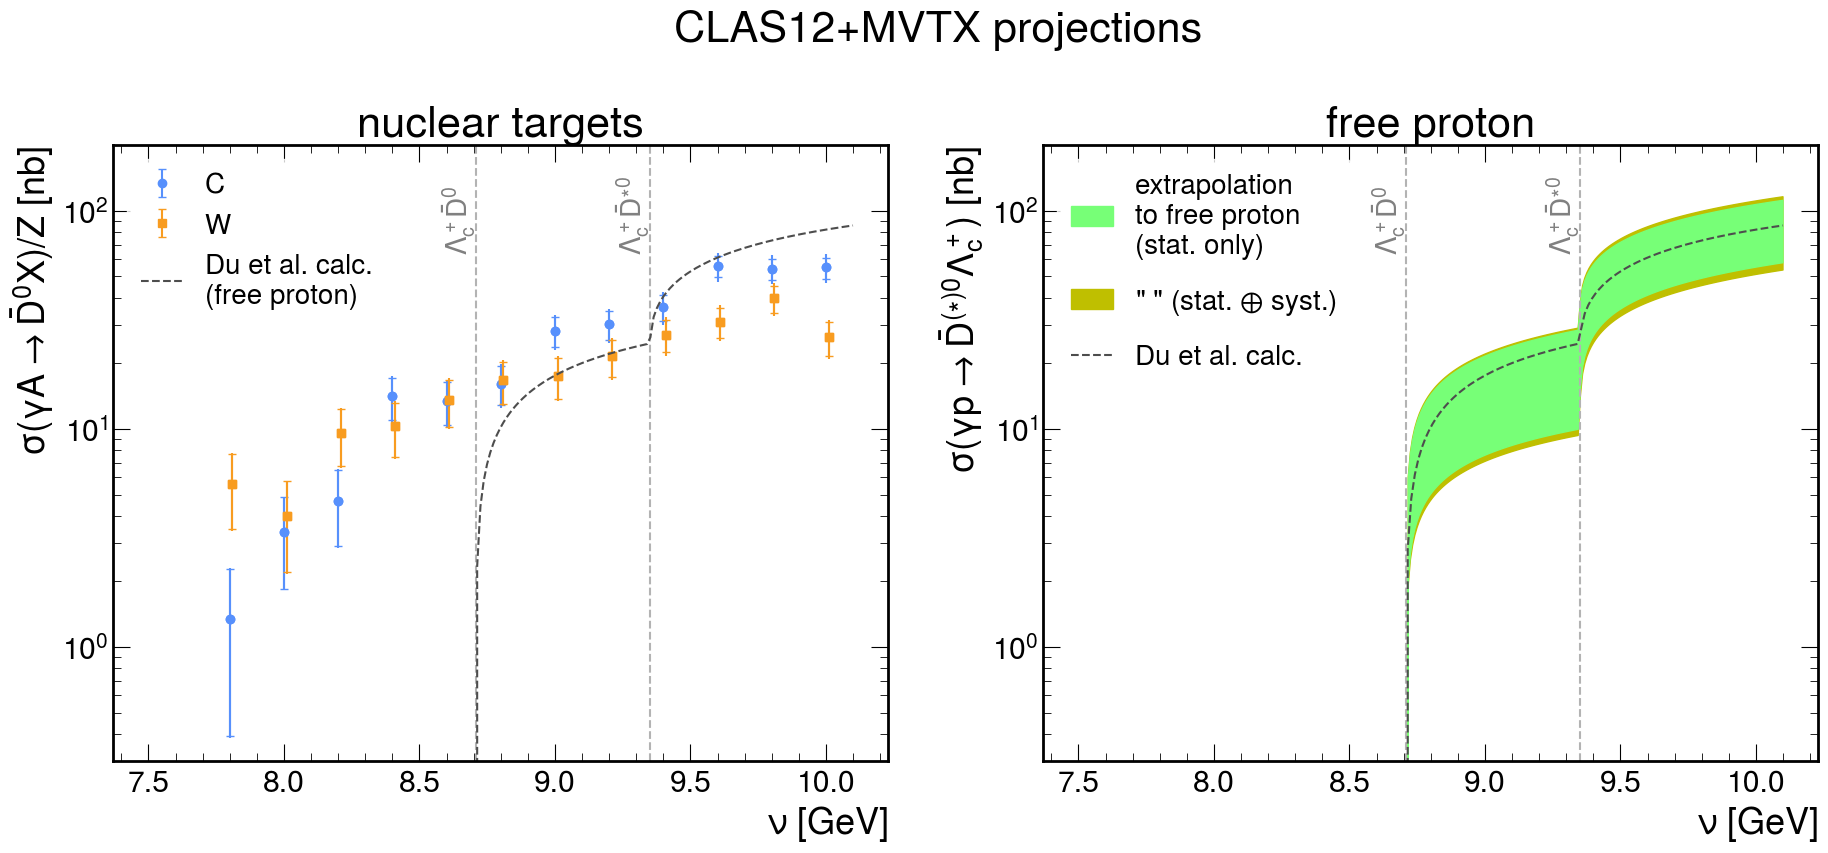

In [53]:
fig, axs=plt.subplots(1,2,figsize=(22,8), sharex='all')#, sharey='all')
plt.sca(axs[0])


#smear function
aa=[]
npoints=100
a=np.linspace(-1, 1,npoints+1)[None,:]
#integral 1-x^2 = x-x^3/3  -> (1-1/3)*2=4/3
w=(1-a**2)*(2/npoints)/(4/3)



nubins=12
numin,numax=7.7,10.1

bc=np.linspace(numin+(numax-numin)/(2*nubins), numax-(numax-numin)/(2*nubins), nubins)


for pF,scale,N, lbl, marker,shift in (pF_C,.85, 480, "C",'o', 0), (pF_W,.55, 280, "W",'s', 0.01):
    sigma=scale*np.sum(fnc(x[:,None]*(1-a*pF/.9383))*w,axis=-1)
    #plt.plot(x,sigma, label=lbl)
    
    
    sigma=scale*np.sum(fnc(bc[:,None]*(1-a*pF/.9383))*w,axis=-1)
    Ni=sigma*N/np.sum(sigma)

    Ni_raffled=np.random.poisson(Ni)
    sigma_raffled=sigma*Ni_raffled/Ni
    dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
    b=plt.errorbar(bc+shift,sigma_raffled,dsigma_raffled, label=lbl, ls='', marker=marker, capsize=3)
    aa.append(b)
    plt.errorbar(bc+shift,sigma_raffled,np.hypot(dsigma_raffled,sigma_raffled*.1), ls='', marker=marker, color=b[0].get_color())
    
    
    #plt.plot(x,scale*np.sum(fnc1(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)
    #plt.plot(x,scale*np.sum(fnc2(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)

plt.yscale('log')

for i in 0,1:
    thr=[8.71,9.35][i]
    plt.axvline(thr, ls='--', color='0.7')
    txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
    plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)

axs[0].set_ylim(3e-1, 2e2)
axs[1].set_ylim(*axs[0].get_ylim())
axs[1].set_yscale('log')
axs[0].set_ylabel("$\\sigma(\\gamma A\\rightarrow \\bar D^{0}X)/Z$ [nb]")
axs[1].set_ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$ [nb]")
plt.xlabel("$\\nu$ [GeV]")
plt.title("nuclear targets")


x=np.linspace(7.7,10.1, 200)
aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.\n(free proton)', ls='--', color='0.3'))

plt.legend(fontsize=20, loc='upper left')


plt.sca(axs[1])


# Approximation for function from the paper, split into D0bar and D0bar* parts.  
def fit_fnc_no_smear(x,p1,p2):
    return p1*np.maximum(x-8.71,0)**.35+ p2*np.maximum(x-9.35,0)**.37
def fit_fnc(x, p1,p2):
    f = fit_fnc_no_smear  
    return np.sum(f(x[:,None]*(1-a*pF/.9383),p1,p2)*w,axis=-1) 


for pF,scale,N, lbl, marker,shift in ((pF_C,.85, 480, "C",'o', 0),):

    #parameters for all trials
    Pvals=[]
    for i in range(300):
    
        sigma=scale*np.sum(fnc(x[:,None]*(1-a*pF/.9383))*w,axis=-1)
        
        
        sigma=scale*np.sum(fnc(bc[:,None]*(1-a*pF/.9383))*w,axis=-1)
        Ni=sigma*N/np.sum(sigma)
    
        Ni_raffled=np.random.poisson(Ni)
        sigma_raffled=sigma*Ni_raffled/Ni
        dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
        P0=50,50
        from scipy.optimize import curve_fit
        P, cov = curve_fit(fit_fnc, bc, sigma_raffled, p0=P0, sigma=dsigma_raffled)
        x=np.linspace(8.5,10.1, 200)
        #print(fit_fnc(x, *P))
        #plt.plot(x, fit_fnc_no_smear(x, *P)/0.85,color='g', alpha=0.1)
        Pvals.append(P)
    m=np.mean(Pvals, axis=0)/scale
    s=np.std(Pvals, axis=0)/scale
print(np.sqrt(cov[0][0])/scale,np.sqrt(cov[1][1])/scale,np.sqrt(abs(cov[0][1]))/scale)
print("mean and stds", m, s)
syst=np.hypot(0.1,0.15)

#plt.fill_between([],[],[], color='w', label="")
aa.append(plt.fill_between(x, fit_fnc_no_smear(x, *(m+s)), fit_fnc_no_smear(x,*(m-s)),color='#77ff77', alpha=1,zorder=-1, 
                           label='extrapolation\nto free proton\n(stat. only)'))
aa.append(plt.fill_between(x, fit_fnc_no_smear(x, *(m+np.hypot(s, m*syst))), fit_fnc_no_smear(x,*(m-np.hypot(s, m*syst))),color='y', alpha=1, zorder=-2, 
                           label='" " (stat. $\oplus$ syst.)'))



# plt.ylim(*axs[0].get_ylim())
# plt.yscale('log')

x=np.linspace(7.5,10.1, 200)
aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.', ls='--', color='0.3'))

plt.legend(fontsize=20, loc='upper left', labelspacing=1)

for i in 0,1:
    thr=[8.71,9.35][i]
    plt.axvline(thr, ls='--', color='0.7')
    txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
    plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)

# print(np.mean(Pvals, axis=0))
plt.xlabel("$\\nu$ [GeV]")
# plt.ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$  [nb]")
plt.title("free proton")
#plt.subplots_adjust(wspace=0)
plt.suptitle("CLAS12+MVTX projections", y=1.05)


plt.savefig("images/reach_smeared.pdf")

[1704.5195208] [[5.17845465e-13]]
[1171.47580081] [[2492.7091442]]
[2155.64415809] [[7562.66913965]]


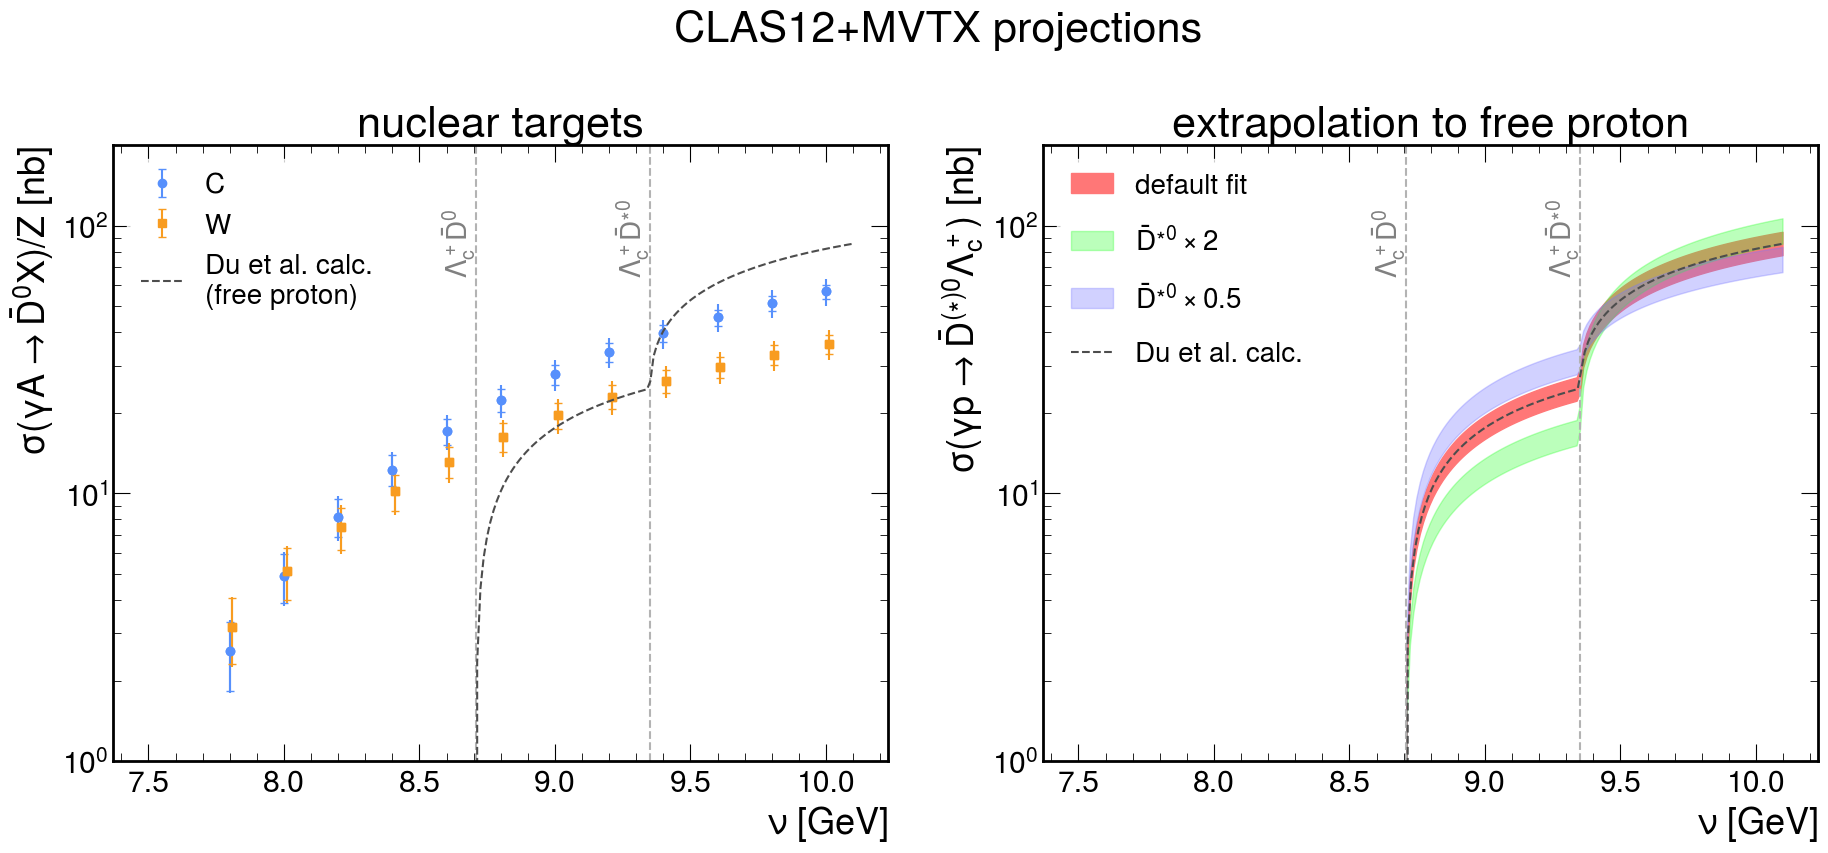

In [57]:
fig, axs=plt.subplots(1,2,figsize=(22,8), sharex='all')#, sharey='all')
plt.sca(axs[0])


#smear function
aa=[]
npoints=100
a=np.linspace(-1, 1,npoints+1)[None,:]
#integral 1-x^2 = x-x^3/3  -> (1-1/3)*2=4/3
w=(1-a**2)*(2/npoints)/(4/3)



nubins=12
numin,numax=7.7,10.1

bc=np.linspace(numin+(numax-numin)/(2*nubins), numax-(numax-numin)/(2*nubins), nubins)


xvals={}
yvals={}
dyvals={}

for pF,scale,N, lbl, marker,shift in (pF_C,.85, 3*504, "C",'o', 0), (pF_W,.55, 3*307, "W",'s', 0.01):
    sigma=scale*np.sum(fnc(x[:,None]*(1-a*pF/.9383))*w,axis=-1)
    #plt.plot(x,sigma, label=lbl)
    
    
    sigma=scale*np.sum(fnc(bc[:,None]*(1-a*pF/.9383))*w,axis=-1)
    Ni=sigma*N/np.sum(sigma)

    #Ni_raffled=np.random.poisson(Ni)
    Ni_raffled=Ni
    
    sigma_raffled=sigma*Ni_raffled/Ni
    dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
    b=plt.errorbar(bc+shift,sigma_raffled,dsigma_raffled, label=lbl, ls='', marker=marker, capsize=3)
    aa.append(b)
    plt.errorbar(bc+shift,sigma_raffled,np.hypot(dsigma_raffled,sigma_raffled*.1), ls='', marker=marker, color=b[0].get_color())
    
    #keep track of the values for both targets
    xvals[lbl]=bc
    yvals[lbl]=sigma_raffled
    dyvals[lbl]=dsigma_raffled
    
    #plt.plot(x,scale*np.sum(fnc1(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)
    #plt.plot(x,scale*np.sum(fnc2(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)

plt.yscale('log')

for i in 0,1:
    thr=[8.71,9.35][i]
    plt.axvline(thr, ls='--', color='0.7')
    txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
    plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)

axs[0].set_ylim(1, 2e2)
axs[1].set_ylim(*axs[0].get_ylim())
axs[1].set_yscale('log')
axs[0].set_ylabel("$\\sigma(\\gamma A\\rightarrow \\bar D^{0}X)/Z$ [nb]")
axs[1].set_ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$ [nb]")
plt.xlabel("$\\nu$ [GeV]")
plt.title("nuclear targets")


x=np.linspace(7.7,10.1, 200)
aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.\n(free proton)', ls='--', color='0.3'))

plt.legend(fontsize=20, loc='upper left')


plt.sca(axs[1])


# Approximation for function from the paper, split into D0bar and D0bar* parts.  
#relative_scale
def fit_fnc_no_smear(x,p1):
    #return p1*(np.maximum(x-8.71,0)**.35+ relative_scale*55/28*np.maximum(x-9.35,0)**.37)
    s=.9383**2+2*x*.9383
    m1=2.286
    m2=1.864
    m3=2.007
    return p1*(np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2))+relative_scale*3800/1700*np.sqrt(lfunc(s,m1**2,m3**2))/(s*(s-.9383**2)))
    
    # def fnc1(nu):
    # s=.9383**2+2*nu*.9383
    # m1=2.286
    # m2=1.864
    # return 1700*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2))
    
    # def fnc2(nu):
    # s=.9383**2+2*nu*.9383
    # m1=2.286
    # m2=2.007
    # return 3800*np.sqrt(lfunc(s,m1**2,m2**2))/(s*(s-.9383**2))

    
    
def fit_fnc(x, p1):
    f = fit_fnc_no_smear  
    return np.sum(f(x[:,None]*(1-a*pF/.9383),p1)*w,axis=-1) 


for relative_scale, color1, color2, label in ((1, '#ff7777', 'y', 'default fit'),
                                              (2, '#33ff3355', 'm', '$\\bar D^{\\ast 0} \\times 2$'), 
                                              (0.5, '#7777ff55', 'c', '$\\bar D^{\\ast 0} \\times 0.5$')):
    #now extract the non-smeared versions of the cross sections from the left hand plot
    params={}
    covs={}
    for pF,lbl in ((pF_C,"C"),(pF_W,"W")):
    
        from scipy.optimize import curve_fit
        P0=50
        P, cov = curve_fit(fit_fnc, xvals[lbl], yvals[lbl], p0=P0, sigma=yvals[lbl], bounds=((0,), (np.inf,)))
        params[lbl]=np.abs(P)
        covs[lbl]=cov
    s=0
    c=(1**(1/3)-12**(1/3))/(184**(1/3)-12**(1/3))
    P_H=params['C']**(1-c)*params['W']**c
    
    #covariance is given by this monster equation
    cov_H=P_H*(P_H[:,None])*((1-c)**2/params['C']/params['C'][:,None]*covs['C']+c**2/params['W']/params['W'][:,None]*covs['W'])
    
    print(P_H, cov_H)
    
    #print(np.sqrt(cov[0][0])/scale,np.sqrt(cov[1][1])/scale,np.sqrt(abs(cov[0][1]))/scale)
    #print("mean and stds", m, s)
    s=np.sqrt((cov_H[0][0]))
    syst=np.hypot(0.1,0.15)
    
    #plt.fill_between([],[],[], color='w', label="")
    aa.append(plt.fill_between(x, fit_fnc_no_smear(x, *(P_H+np.hypot(s,P_H*.1))), fit_fnc_no_smear(x,*(P_H-np.hypot(s,P_H*.1))),color=color1,zorder=-1, 
                               label=label))
    #aa.append(plt.fill_between(x, fit_fnc_no_smear(x, *(P_H+np.hypot(s, P_H*syst))), fit_fnc_no_smear(x,*(P_H-np.hypot(s, P_H*syst))),color=color2, alpha=1, zorder=-2, 
    #                           label='" " (stat. $\oplus$ syst.)'))



# plt.ylim(*axs[0].get_ylim())
# plt.yscale('log')

x=np.linspace(7.5,10.1, 200)
aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.', ls='--', color='0.3'))

plt.legend(fontsize=20, loc='upper left', labelspacing=1)

for i in 0,1:
    thr=[8.71,9.35][i]
    plt.axvline(thr, ls='--', color='0.7')
    txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
    plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)

# print(np.mean(Pvals, axis=0))
plt.xlabel("$\\nu$ [GeV]")
# plt.ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$  [nb]")
plt.title("extrapolation to free proton")
#plt.subplots_adjust(wspace=0)
plt.suptitle("CLAS12+MVTX projections", y=1.05)


plt.savefig("images/reach_smeared.pdf")

In [10]:
m*(m[:,None])*((1-c)**2/params['C']/params['C'][:,None]*covs['C']+c**2/params['W']/params['W'][:,None]*covs['W'])

array([[0.80408524, 2.11957936],
       [2.11957936, 5.58723933]])

[ 7.5         7.51306533  7.52613065  7.53919598  7.55226131  7.56532663
  7.57839196  7.59145729  7.60452261  7.61758794  7.63065327  7.64371859
  7.65678392  7.66984925  7.68291457  7.6959799   7.70904523  7.72211055
  7.73517588  7.74824121  7.76130653  7.77437186  7.78743719  7.80050251
  7.81356784  7.82663317  7.83969849  7.85276382  7.86582915  7.87889447
  7.8919598   7.90502513  7.91809045  7.93115578  7.94422111  7.95728643
  7.97035176  7.98341709  7.99648241  8.00954774  8.02261307  8.03567839
  8.04874372  8.06180905  8.07487437  8.0879397   8.10100503  8.11407035
  8.12713568  8.14020101  8.15326633  8.16633166  8.17939698  8.19246231
  8.20552764  8.21859296  8.23165829  8.24472362  8.25778894  8.27085427
  8.2839196   8.29698492  8.31005025  8.32311558  8.3361809   8.34924623
  8.36231156  8.37537688  8.38844221  8.40150754  8.41457286  8.42763819
  8.44070352  8.45376884  8.46683417  8.4798995   8.49296482  8.50603015
  8.51909548  8.5321608   8.54522613  8.55829146  8

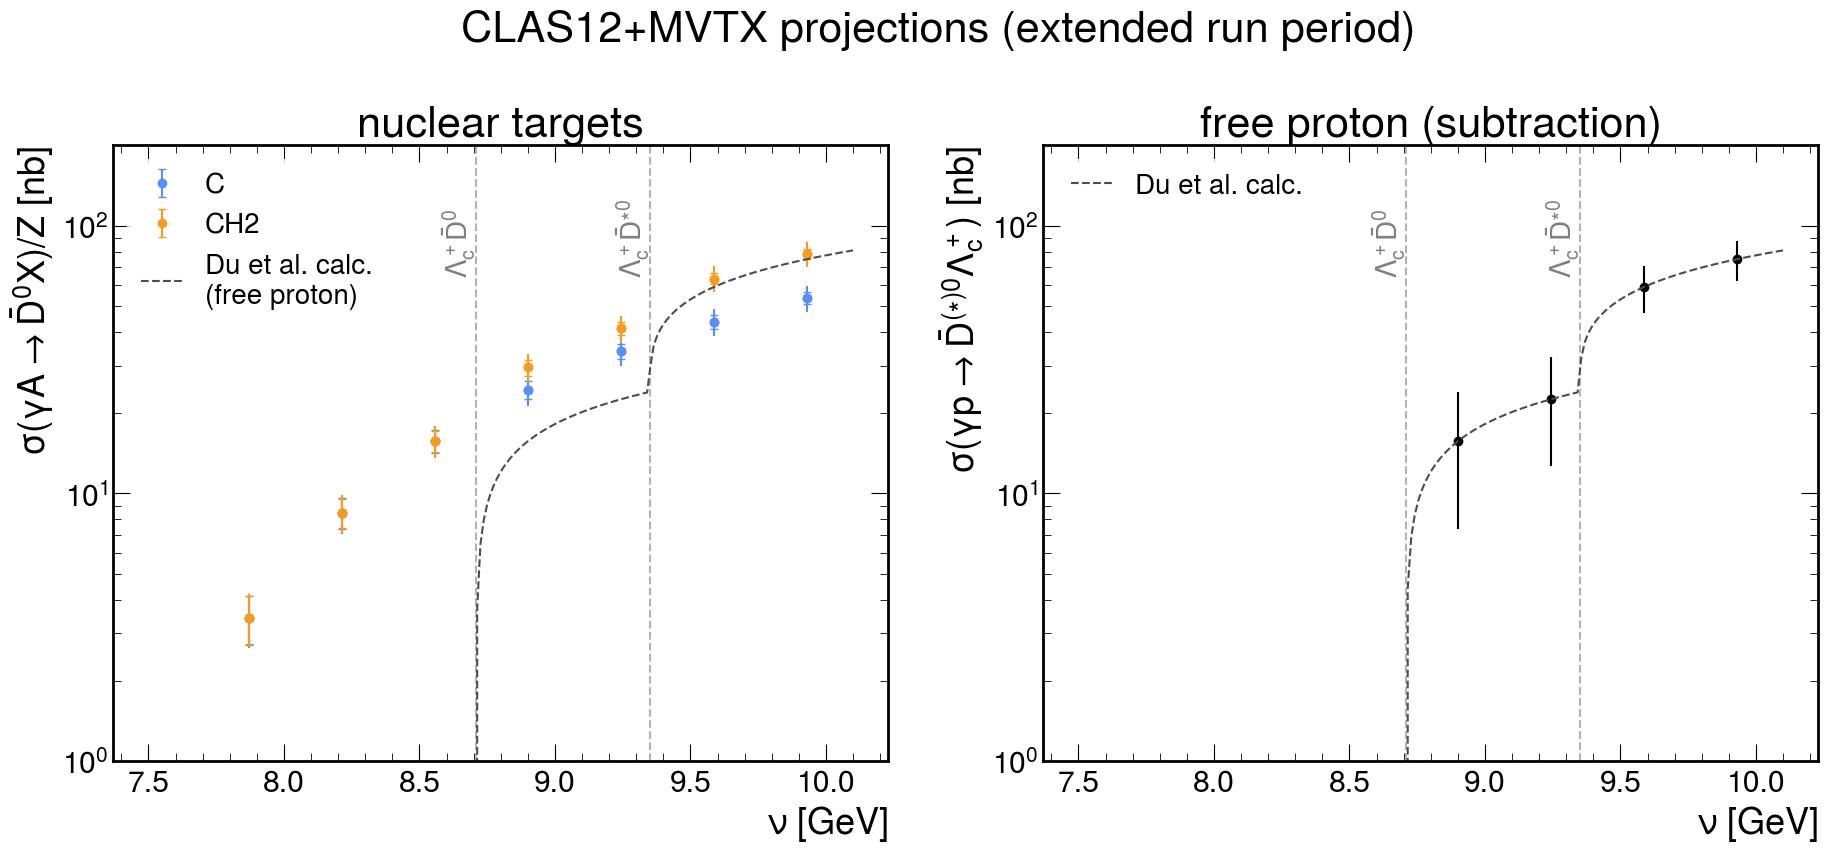

In [12]:
fig, axs=plt.subplots(1,2,figsize=(22,8), sharex='all')#, sharey='all')
plt.sca(axs[0])


#smear function
aa=[]
npoints=100
a=np.linspace(-1, 1,npoints+1)[None,:]
#integral 1-x^2 = x-x^3/3  -> (1-1/3)*2=4/3
w=(1-a**2)*(2/npoints)/(4/3)

print(x)

nubins=7
numin,numax=7.7,10.1
bins=np.array([8.7, 9.35, 9.7, 10.1])

bc=(bins[1:]+bins[:-1])/2#
bc=np.linspace(numin+(numax-numin)/(2*nubins), numax-(numax-numin)/(2*nubins), nubins)
bw=(bins[:-1]-bins[1:])

xvals={}
yvals={}
dyvals={}

#, (pF_W,.55, 307, "CH2",'s', 0.01):
for target in "C", "CH2":
    pF,scale,N, lbl, marker,shift = (pF_C,.85, 504, "C",'o', 0)
    sigma=scale*np.sum(fnc(bc[:,None]*(1-a*pF/.9383))*w,axis=-1)

    N*=3.87/1.56
    if target=="CH2":
        sigma += fnc(bc)*2/6 
        N=N*(1+2/6/scale)
    Ni=sigma*N/np.sum(sigma)

    #Ni_raffled=np.random.poisson(Ni)
    Ni_raffled=Ni
    
    sigma_raffled=sigma*Ni_raffled/Ni
    dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
    b=plt.errorbar(bc+shift,sigma_raffled,dsigma_raffled, label=target, ls='', marker=marker, capsize=3)
    aa.append(b)
    plt.errorbar(bc+shift,sigma_raffled,np.hypot(dsigma_raffled,sigma_raffled*.1), ls='', marker=marker, color=b[0].get_color())
    
    #keep track of the values for both targets
    xvals[target]=bc
    yvals[target]=sigma_raffled
    dyvals[target]=dsigma_raffled
    
    #plt.plot(x,scale*np.sum(fnc1(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)
    #plt.plot(x,scale*np.sum(fnc2(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)


plt.yscale('log')

for i in 0,1:
    thr=[8.71,9.35][i]
    plt.axvline(thr, ls='--', color='0.7')
    txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
    plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)

axs[0].set_ylim(1, 2e2)
axs[1].set_ylim(*axs[0].get_ylim())
axs[1].set_yscale('log')
axs[0].set_ylabel("$\\sigma(\\gamma A\\rightarrow \\bar D^{0}X)/Z$ [nb]")
axs[1].set_ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$ [nb]")
plt.xlabel("$\\nu$ [GeV]")
plt.title("nuclear targets")


x=np.linspace(7.7,10.1, 200)
aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.\n(free proton)', ls='--', color='0.3'))

plt.legend(fontsize=20, loc='upper left')


plt.sca(axs[1])

selection=xvals['C']>8.65
plt.errorbar(xvals['C'][selection], (yvals['CH2']-yvals['C'])[selection]*6/2, np.hypot(dyvals['CH2'],dyvals['C'])[selection]*6/2, color='k', 
             marker='o', ls='')
#print(


x=np.linspace(7.5,10.1, 200)
aa.append(plt.errorbar(x, fnc(x), label='Du et al. calc.', ls='--', color='0.3'))

plt.legend(fontsize=20, loc='upper left', labelspacing=1)

for i in 0,1:
    thr=[8.71,9.35][i]
    plt.axvline(thr, ls='--', color='0.7')
    txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
    plt.text(thr-.13, 70, txt, rotation=90, color='0.5', fontsize=20)

# print(np.mean(Pvals, axis=0))
plt.xlabel("$\\nu$ [GeV]")
# plt.ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$  [nb]")
plt.title("free proton (subtraction)")
#plt.subplots_adjust(wspace=0)
plt.suptitle("CLAS12+MVTX projections (extended run period)", y=1.05)


plt.savefig("images/reach_smeared_CH2.pdf")

/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_36551/1252234887.py:36: RuntimeWarning: invalid value encountered in divide
  dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
/var/folders/_x/mzz2_hcx0dg4mv6b9blzjpp40000gn/T/ipykernel_36551/1252234887.py:39: OptimizeWarning: Covariance of the parameters could not be estimated
  P, cov = curve_fit(fit_fnc, bc, sigma_raffled, p0=P0, sigma=dsigma_raffled)


[21.87206434 49.48862812]


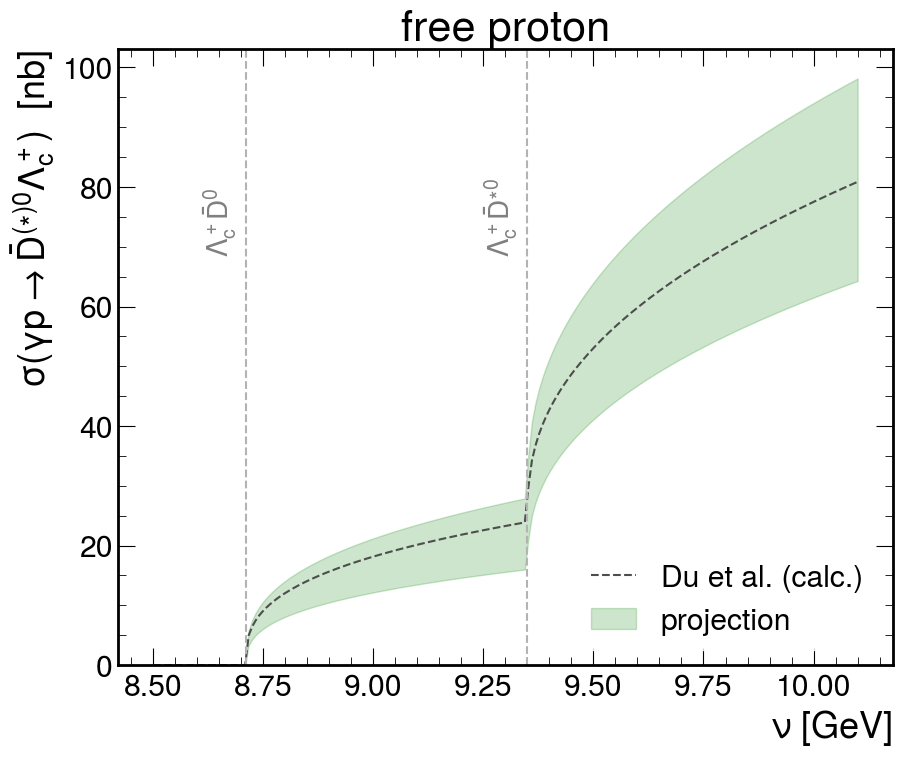

In [8]:
x=np.linspace(8.5,10.1, 200)


npoints=100
a=np.linspace(-1, 1,npoints+1)[None,:]

plt.plot(x, fnc(x), label='Du et al. (calc.)', ls='--', color='0.3')

w=(1-a**2)*(2/npoints)/(4/3)

nubins=14
numin,numax=7.5,10.1

bc=np.linspace(numin+(numax-numin)/(2*nubins), numax-(numax-numin)/(2*nubins), nubins)


def fit_fnc_no_smear(x,p1,p2):
    return p1*np.maximum(x-8.71,0)**.35+ p2*np.maximum(x-9.35,0)**.37
def fit_fnc(x, p1,p2):
    f = fit_fnc_no_smear  
    
    return np.sum(f(x[:,None]*(1-a*pF/.9383),p1,p2)*w,axis=-1) 

#parameters for all trials
Pvals=[]
for i in range(300):
    for pF,scale,N, lbl, marker,shift in ((pF_C,.85, 1000, "C",'o', 0),):
        sigma=scale*np.sum(fnc(x[:,None]*(1-a*pF/.9383))*w,axis=-1)
        
        
        sigma=scale*np.sum(fnc(bc[:,None]*(1-a*pF/.9383))*w,axis=-1)
        Ni=sigma*N/np.sum(sigma)
    
        Ni_raffled=np.random.poisson(Ni)
        sigma_raffled=sigma*Ni_raffled/Ni
        dsigma_raffled=sigma_raffled/np.sqrt(Ni_raffled)
        P0=50,50
        from scipy.optimize import curve_fit
        P, cov = curve_fit(fit_fnc, bc, sigma_raffled, p0=P0, sigma=dsigma_raffled)
        x=np.linspace(8.5,10.1, 200)
        #print(fit_fnc(x, *P))
        #plt.plot(x, fit_fnc_no_smear(x, *P)/0.85,color='g', alpha=0.1)
        Pvals.append(P)


m=np.mean(Pvals, axis=0)/0.85
s=np.std(Pvals, axis=0)/0.85
plt.fill_between(x, fit_fnc_no_smear(x, *(m+np.hypot(s, m*.012))), fit_fnc_no_smear(x,*(m-np.hypot(s, m*.012))),color='g', alpha=0.2, label='projection')

plt.ylim(0)

plt.legend()

for i in 0,1:
    thr=[8.71,9.35][i]
    plt.axvline(thr, ls='--', color='0.7')
    txt='$\\Lambda_c^+\\bar D^0$' if i ==0 else '$\\Lambda_c^+\\bar D^{\\ast 0}$'
    plt.text(thr-.1, 70, txt, rotation=90, color='0.5', fontsize=20)

print(np.mean(Pvals, axis=0))
plt.xlabel("$\\nu$ [GeV]")
plt.ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$  [nb]")
plt.title("free proton")
plt.savefig("images/reach_smeared_free_proton.pdf")

[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         16.85019391
 26.67684668 32.54223905 37.00783396 40.70585998 41.5544702  41.87532128
 42.19167061 42.50367515 42.81148325 43.11523529 43.41506425 43.71109626
 44.00345103 44.29224236 44.57757847 44.85956241 45.13829238 45.41386204
 45.68636078 45.95587402 46.22248342 46.4862671  46.74729987 47.0056534
 47.26139643 47.51459488 47.76531206 48.01360878 48.25954348 48.50317239
 48.74454959 48.98372719 49.22075536 49.455

Text(1, 0, '$\\nu$ [GeV]')

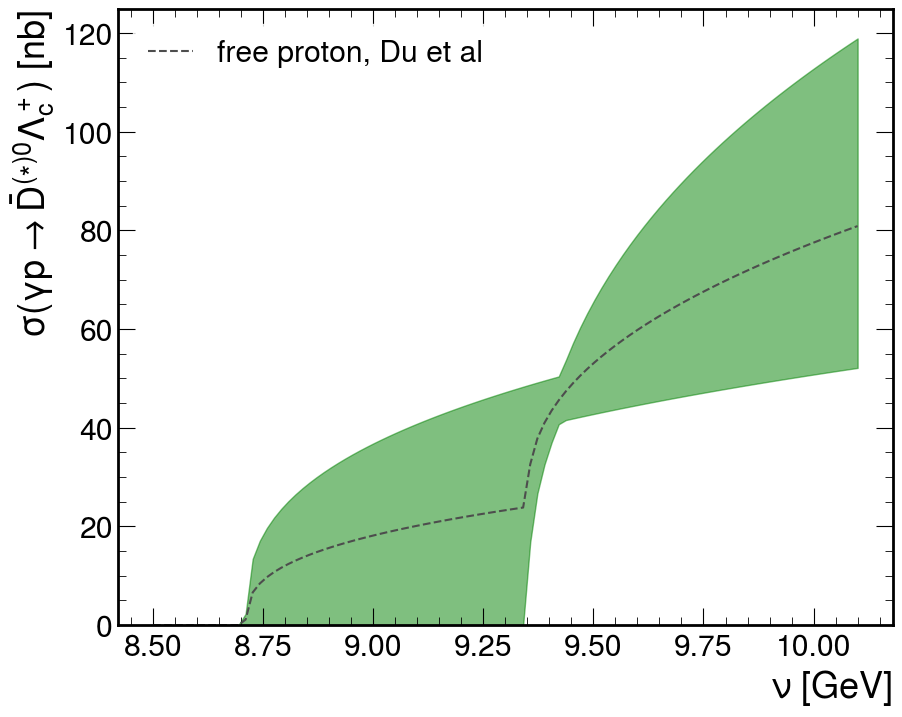

In [140]:
x=np.linspace(8.5,10.1, 100)

plt.plot(x, fnc(x), label='free proton, Du et al', ls='--', color='0.3')

integral1=np.sum(fnc1(x))
integral2=np.sum(fnc2(x))
integral=integral1+integral2

upper=1.1*np.maximum(fnc1(x)*integral/integral1,fnc2(x)*integral/integral2)
lower=0.9*np.minimum(fnc1(x)*integral/integral1,fnc2(x)*integral/integral2)
print(lower)
plt.fill_between(x,upper, lower, color='g', alpha=0.5)

plt.legend()
#plt.yscale('log')
plt.ylim(0)
plt.ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^{(\\ast)0}\\Lambda_c^+)$ [nb]")
plt.xlabel("$\\nu$ [GeV]")

Text(1, 0, '$\\nu$ [GeV]')

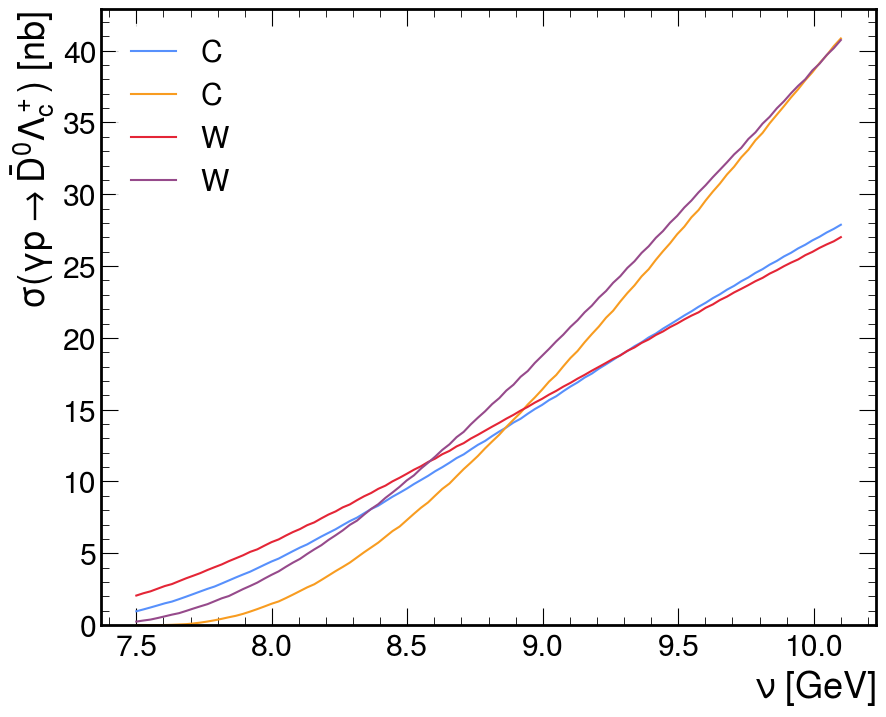

In [85]:

x=np.linspace(7.5,10.1, 100)


npoints=100
a=np.linspace(-1, 1,npoints+1)[None,:]

#integral 1-x^2 = x-x^3/3  -> (1-1/3)*2=4/3

w=(1-a**2)*(2/npoints)/(4/3)


#plt.plot(x, fnc(x), label='H')

for pF,scale, lbl in (pF_C,1, "C"), (pF_W,1, "W"):
    plt.plot(x,scale*np.sum(fnc1(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)
    plt.plot(x,scale*np.sum(fnc2(x[:,None]*(1-a*pF/.9383))*w,axis=-1), label=lbl)

plt.legend()
plt.ylim(0)
plt.ylabel("$\\sigma(\\gamma p\\rightarrow \\bar D^0\\Lambda_c^+)$ [nb]")
plt.xlabel("$\\nu$ [GeV]")
plt.

In [27]:
#help(plt.legend)

In [26]:
.85*np.exp((1**(1/3)-12**(1/3))/(184**(1/3)-12**(1/3))*np.log(.55/.85))

np.float64(1.002658543061357)